## Group 73 
### Students:
### - Adam Bailes
### - Jasser Dhaouadi
### - William Leblanc

# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
Replace this sentence with your answer. 

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
Replace this sentence with your answer.

## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
Replace this sentence with your answer.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  
Replace this sentence with your answer.

### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
Replace this sentence with your answer.

### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work


**4.3 Answer:**  


**Transformations or New Features**

- We created four engineered features based on patterns identified during EDA: 
    - two **log transformations**:
        - *log_sqft* = log(1 + *calculatedfinishedsquarefeet*)
        - *log_lotsize* = log(1 + *lotsizesquarefeet*)
    - two **interaction features**:
        - *sqft_x_bath* = *calculatedfinishedsquarefeet* × *bathroomcnt*
        - *bed_bath_ratio* = *bedroomcnt* / (*bathroomcnt* + 1)  [<u>ratio feature</u>] 
- These features were intended to capture information that might not be fully represented by the original variables alone, especially **skewness**, **combined effects** between variables, and **structural balance** within a property.

<br>

**Why We Created Them**

- The two **log features** were created because both *finished square footage* and *lot size* were **right-skewed**, so applying a log transformation helped <u>reduce the influence of extreme values</u> and better reflect possible <u>nonlinear relationships</u> with the target. 
- The **interaction feature** *sqft_x_bath* was created to capture the **joint effect** of *house size* and *bathroom count*, since larger homes with more bathrooms may represent a different value pattern than either variable alone. 
- The *bed_bath_ratio* feature was designed to summarize the **relationship** between *bedrooms* and *bathrooms* and represent how balanced the internal layout of a property is.


<br>

**Useful and Less Useful Features**

- The <u>most useful</u> engineered features were *log_sqft* and *sqft_x_bath*: 
    - In Milestone 1, *sqft_x_bath* showed one of the strongest F-scores among the engineered variables
    - In Milestone 2, both *log_sqft* and *sqft_x_bath* were retained during **feature selection** for Bagging and Random Forest, indicating that they carried meaningful predictive signal. 
- The <u>less useful</u> engineered features were *log_lotsize* and *bed_bath_ratio*:
    - Although both were reasonable to test, *log_lotsize* was based on a weaker predictor than interior living area, and *bed_bath_ratio* likely oversimplified information already available in the original bedroom and bathroom variables.

<br>

**What Worked and What Did Not Work**

- <u>What worked</u> was the logic behind the feature engineering and the fact that some engineered features, especially *log_sqft* and *sqft_x_bath*, captured real signal in the data. 
- <u>What did NOT work</u> was improving final model accuracy: 
    - after adding the engineered features, MAE became slightly worse for Bagging, Random Forest, and HistGradientBoosting. 
    - This suggests that although the new variables were informative, the tree-based ensemble models were already able to learn nonlinear relationships and interactions directly from the original cleaned dataset. 
    - As a result, the engineered feature set was useful for analysis, but it did not outperform the original feature set in the final models.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model


**4.4 Answer:**  

**Models We Tried and Why**

- We evaluated three <u>tree-based</u> ensemble regression models: 
    1. **Bagging Regressor**
    2. **Random Forest Regressor**
    3. **HistGradientBoosting Regressor**

- These models were chosen because the Zillow housing dataset contains <u>mixed feature types, nonlinear relationships, and possible interactions among structural and location variables</u>, and tree-based methods are well suited for handling those patterns without requiring strong linearity assumptions. 
- We also already saw from earlier analysis that the problem was a regression task with potentially complex relationships, so ensemble methods were a natural choice. 
- Across the milestone, we compared these models under different feature setups, including the original cleaned feature set, the engineered feature set, and reduced feature subsets.

<br>

**How We Evaluated Generalization**

- We evaluated generalization primarily using **Mean Absolute Error (MAE)** with **Repeated K-Fold Cross-Validation** (5 folds × 5 repeats) on the training data: 
    - **MAE** was used because it is easy to interpret in dollars and directly reflects average prediction error for housing prices. 
    - **Repeated cross-validation** gave a more stable estimate of model performance than a single split, and we recorded both the **mean MAE** and the **standard deviation** across **folds** to assess both **accuracy** and **consistency**. 
- After selecting the **final model**, we also evaluated it on a **held-out test set**:
    - The **final Random Forest** achieved a CV MAE of **198,962.46** with standard deviation **3,480.95**, and a test MAE of **194,860.97**, which showed that the model generalized well and did not show evidence of strong overfitting.

<br>

**Hyperparameter Tuning**

- We used a **two-step tuning strategy** for all three models. 
    - First, we performed **parameter sweeps** to understand how major hyperparameters affected **MAE** and to identify reasonable **search ranges**. 
    - Then we applied a more **focused tuning method** for each model: 
        - **RandomizedSearchCV** for Random Forest
        - **GridSearchCV** for Bagging
        - **Optuna** for HistGradientBoosting. 

- For **Random Forest**, we tuned parameters such as *n_estimators*, *max_depth*, *min_samples_split*, *min_samples_leaf*, and *max_features*
- for **Bagging**, we tuned *n_estimators*, *max_samples*, and *max_features*
- for **HistGradientBoosting**, we tuned *learning_rate*, *max_depth*, *max_iter*, and *min_samples_leaf*

- **After tuning**, all three models improved over their baselines, with:
    - Random Forest improving from **201,045** to **198,962** **MAE**
    - Bagging from **209,263** to **202,453**
    - HistGradientBoosting from **204,429** to **203,320**


<br>

**How We Chose the Final Model**

- We selected **Random Forest Regressor** as the <u>final model</u> because it achieved the **lowest tuned cross-validation MAE** among all models, while also showing **stable performance** across folds. 
- Its best hyperparameters were:
    - *n_estimators*=191
    - *max_depth* = 19
    - *max_features* = 'sqrt'
    - *min_samples_leaf* = 2
    - *min_samples_split* = 5

- Another important factor was that Random Forest performed best using the <u>original cleaned feature set</u>, whereas the engineered and reduced feature sets did not produce better results overall. 
- Although Bagging improved the most relative to its baseline, it still did not surpass Random Forest in absolute performance, and HistGradientBoosting remained slightly weaker. 
- Based on <u>cross-validation accuracy, stability, and held-out test performance</u>, **Random Forest** was the strongest overall choice for the final project.

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance


**5.1 Answer:**  


**Key Metrics**

- We evaluated model performance primarily using **Mean Absolute Error (MAE)**, which measures the average absolute difference between predicted and actual house prices. 
- In practical terms, **MAE** shows <u>how far the model’s predictions are off, on average, in dollars</u>. 
- The **final Random Forest** model achieved a cross-validation MAE of **$198,962.46** and a test MAE of **$194,860.97**, meaning that predictions were typically off by about **$195K–$199K** per property. 
- We used **MAE** as the main metric because it is directly **interpretable** for a housing price prediction problem and gives a clear sense of **practical prediction error**

<br>

**Comparison Across Models**

- Among the three models tested, **Random Forest** performed best overall, followed by **HistGradientBoosting** and then **Bagging**. 
- <u>After tuning</u>, Random Forest achieved the lowest cross-validation MAE (**$198,962**), compared with **$202,453** for Bagging and **$203,320** for HistGradientBoosting. This shows that Random Forest produced the most accurate predictions on unseen validation folds. 
- Although all three models improved after tuning (compared to baseline performances), the differences indicate that **Random Forest** captured the structure of the data slightly better than the other two ensemble methods.

<br>

**Training vs Validation/Test Performance**

- To evaluate **generalization**, we used **Repeated K-Fold Cross-Validation** (5 folds × 5 repeats) and then confirmed the final result on a **held-out test set**. 
- The **final Random Forest model** had:
    - **cross-validation MAE** of **$198,962.46** with a **standard deviation** of **$3,480.95** 
    - **test MAE** was **$194,860.97**. 
- Because the test performance was very close to the validation performance, the model showed good **stability** and **no** strong evidence of **overfitting**. In other words, the error remained consistent when moving from training-based validation to completely unseen data.

<br>

**Interpretation of the Results**

- Overall, the results show that the model was able to learn meaningful pricing patterns from the Zillow dataset, but the prediction error is still large in practical terms. 
- An average error of around **$195K** means the model is useful for identifying broad market trends and relative property values, but it is not accurate enough to serve as a precise pricing tool for individual homes. 
- This is not surprising, since real estate prices depend on many factors that may not be fully captured in the available features. 
- Therefore, the final model worked well as a predictive benchmark and produced stable generalization results, but its predictions should still be interpreted as approximate rather than exact valuations.

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters



**5.2 Answer:**  

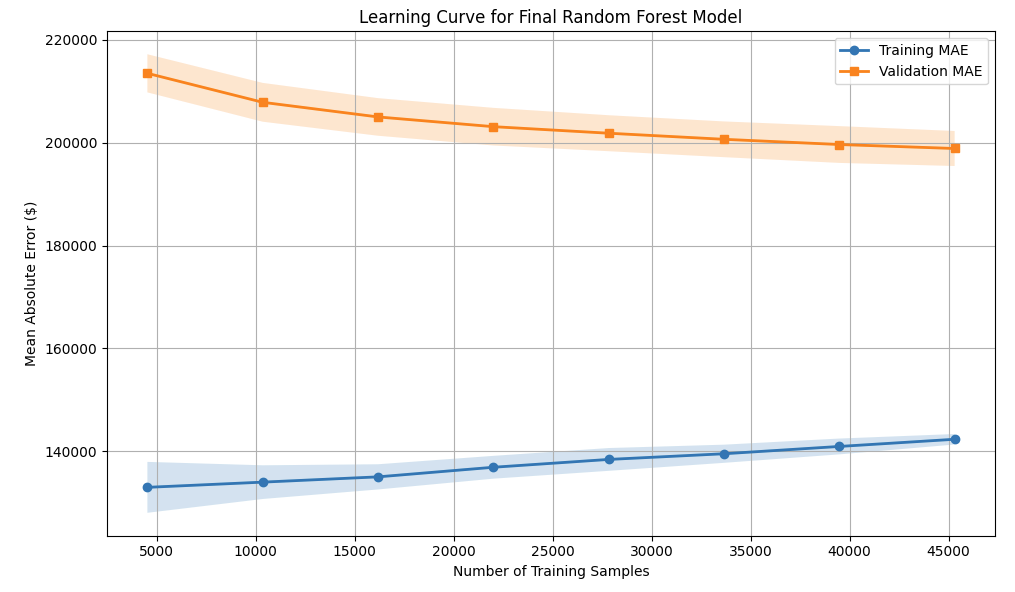


<br> 

**Figure: Learning Curve for Final Random Forest Model**

- **Title**: Learning Curve for Final Random Forest Model
- **X-axis**: Number of Training Samples
- **Y-axis**: Mean Absolute Error ($)
- **Lines**: Training MAE and Validation MAE

<br>

**Explanation of What the Plot Shows**

This plot was generated by fitting the final Random Forest model on **progressively larger portions of the training set** and evaluating performance at each training size. For every sample size shown on the x-axis, the model was trained and then evaluated using the same **Repeated K-Fold Cross-Validation (5 folds × 5 repeats)** strategy used throughout model selection. The graph therefore shows how both **training MAE** and **validation MAE** change as more training data is added. The training MAE starts lower, around **$133K**, and gradually increases to about **$142K** as the sample size grows, while the validation MAE decreases from about **$213K** to about **$199K**. This pattern is expected because with smaller samples the model can fit the training data more closely, but as more observations are included, training error rises slightly while validation performance improves. The shaded regions around both curves represent variation across the repeated cross-validation folds.

<br>

**Why This Visualization Matters**

This visualization is important because it helps us evaluate **generalization** and **model behavior**, not just final accuracy. The downward trend in validation MAE shows that the model benefits from having more data, which is a positive sign. At the same time, there is still a noticeable gap between the training and validation curves, meaning the model fits the training data better than unseen data and still shows some degree of overfitting. However, the validation curve becomes flatter at larger sample sizes, suggesting that performance is beginning to stabilize. Overall, this plot matters because it provides visual evidence that the final Random Forest model generalizes reasonably well, improves as more data is used, and is appropriate as the final model, even though prediction error remains substantial in practical terms.

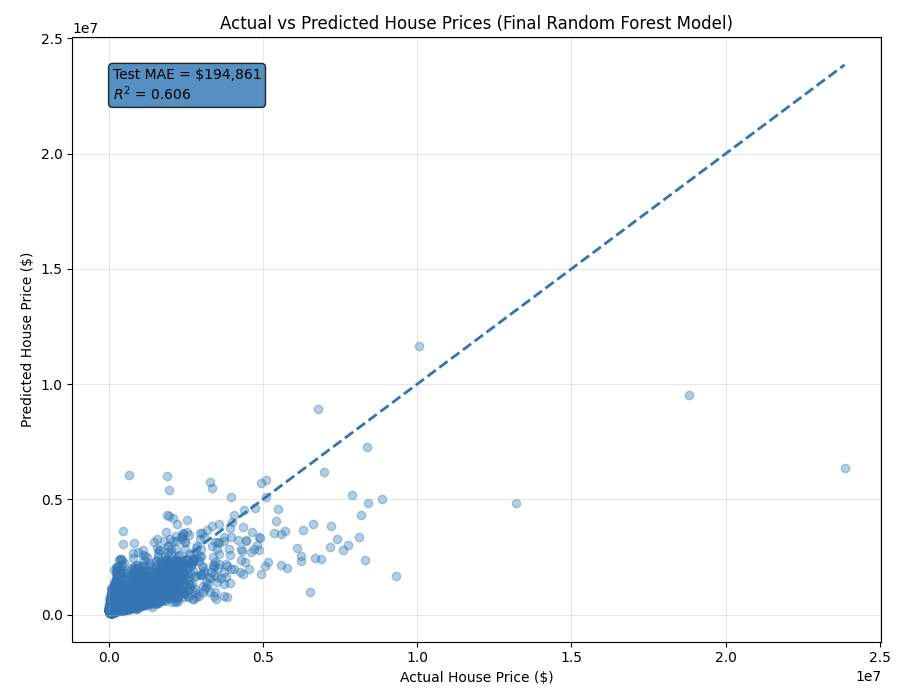


<br>

**Figure: Actual vs Predicted House Prices for Final Random Forest Model**

- **Title**: Actual vs Predicted House Prices (Final Random Forest Model)
- **X-axis**: Actual House Price ($)
- **Y-axis**: Predicted House Price ($)
- **Reference line**: Dashed 45-degree line representing perfect predictions
- **Reported metrics** on plot: 
    - **Test MAE** = $194,861, 
    - **R^2** = 0.606

<br>

**Explanation of What the Plot Shows**

This scatter plot compares the actual house prices in the test set to the prices predicted by the final Random Forest model. If predictions were perfect, all points would lie directly on the dashed 45-degree line. In the plot, a large number of homes in the low-to-mid price range cluster relatively close to the line, which shows that the model captures the general pricing pattern reasonably well. This is also consistent with the reported **R^2 of 0.606**, meaning the model explains about **60.6% of the variation** in house prices on the test set. However, the spread of points becomes wider as actual prices increase, and several very expensive homes fall far below the reference line, indicating that the model tends to **underpredict high-value properties**. There are also a few cases above the line, showing occasional overprediction, but underprediction at the upper end is more visually noticeable.

<br>

**Why This Visualization Matters**

- This visualization matters because it shows model behavior in a way that a single summary metric cannot. The **MAE of $194,861** tells us the average prediction error, but the scatter plot reveals **where** those errors occur. 
- In this case, it shows that the model performs better for the majority of lower and moderately priced homes, while prediction accuracy becomes weaker for luxury properties and extreme values. 
- This is important for interpreting the final model realistically: 
    - the Random Forest captures overall market structure fairly well, but it is less reliable at the highest price ranges. 
    - That makes this plot especially useful for explaining both the strengths and the limitations of the final model on unseen test data.

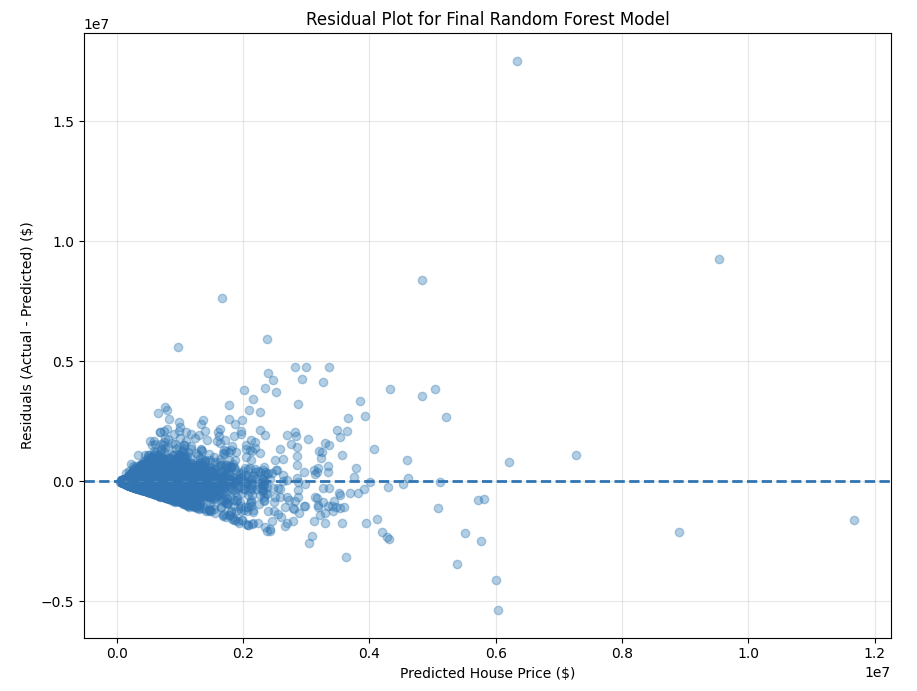

**Figure: Residual Plot for Final Random Forest Model**

- **Title**: Residual Plot for Final Random Forest Model
- **X-axis**: Predicted House Price ($)
- **Y-axis**: Residuals (Actual - Predicted) ($)
- **Reference line**: Horizontal dashed line at 0 residual

<br>

**Explanation of What the Plot Shows**

- This residual plot shows the prediction errors of the final Random Forest model on the test set. 
- Points near the zero line indicate more accurate predictions, while points farther away indicate larger errors. 
- Most homes with lower predicted prices are clustered relatively close to zero, but the spread becomes wider as predicted price increases, indicating larger errors for higher-priced homes.

<br>

**Why This Visualization Matters**

- This visualization matters because it helps verify whether model errors remain consistent across the prediction range. 
- In this case, the pattern suggests that the model performs more consistently for lower- and mid-priced homes than for expensive properties. 
- This supports the overall interpretation of the final model while leaving a more detailed discussion for the error analysis section.

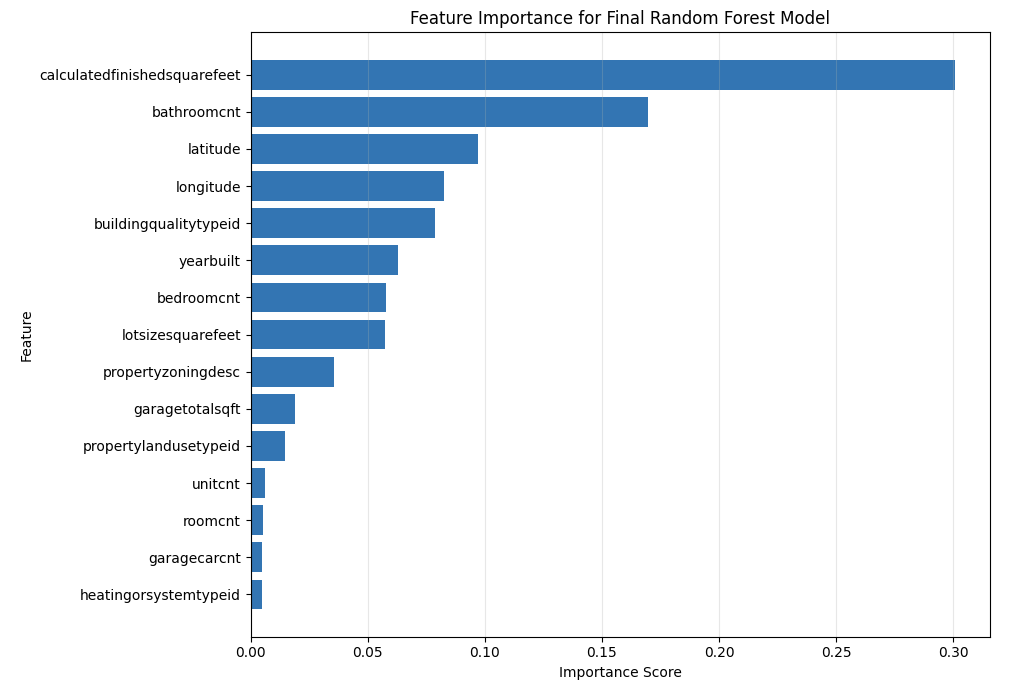

**Figure: Feature Importance for Final Random Forest Model**

- **Title**: Feature Importance for Final Random Forest Model
- **X-axis**: Importance Score
- **Y-axis**: Feature

<br>

**Explanation of What the Plot Shows**

- This plot ranks the predictors according to how much they contributed to the final Random Forest model:
    - The most important feature is *calculatedfinishedsquarefeet*, with a clearly larger importance score than all other variables, showing that interior living area was the strongest driver of predictions. 
    - The next most influential features are *bathroomcnt*, *latitude*, *longitude*, *buildingqualitytypeid*, and *yearbuilt*, which indicates that both structural characteristics and location-related variables played a major role. 
    - Features such as *garagecarcnt*, *heatingorsystemtypeid*, and *roomcnt* had much smaller importance scores, meaning they contributed less to the final predictions.

<br>

**Why This Visualization Matters**

- This visualization matters because it makes the final model more interpretable by showing **which variables** had the greatest **influence** on house price prediction. 
- It also supports earlier findings from EDA and feature analysis, especially the strong role of *finished square footage* and the importance of location. 
- Overall, the plot helps connect model performance back to the actual housing attributes that were most useful in predicting property values.

![baseline VStunedRESULTS.png](<attachment:baseline VStunedRESULTS.png>) 


**Figure: Baseline vs Tuned Model Performance**

- **Title**: Baseline vs Tuned Model Performance
- **X-axis**: Model
- **Y-axis**: Mean Absolute Error ($)
- **Bars**: Baseline and Tuned model MAE
- **Error bars**: Standard deviation across cross-validation folds
- **Annotated values**: Each bar is labeled with its MAE and standard deviation

<br>

**Explanation of What the Plot Shows**

- This plot compares the baseline and tuned versions of Bagging, Random Forest, and HistGradientBoosting using mean cross-validation MAE, with error bars showing the standard deviation. 
- Hyperparameter tuning improved all three models
    - **Bagging** improved from **$209,263 to $202,453**
    - **Random Forest** improved from **$201,045 to $198,962**
    - **HistGradientBoosting** improved from **$204,429 to $203,320**. 
- Among all results, the tuned **Random Forest** achieved the **lowest MAE**, while the tuned versions of all three models also showed relatively similar and moderate variability, with standard deviations roughly between **$3.3K** and **$4.6K**.

<br>

**Why This Visualization Matters**

- This visualization matters because it summarizes both accuracy and stability in one figure. 
- It shows that tuning consistently reduced prediction error across all models, which confirms that the hyperparameter search was effective. 
- It also makes the final model choice easier to justify, since Random Forest not only had the best tuned performance but also remained stable across repeated validation folds.
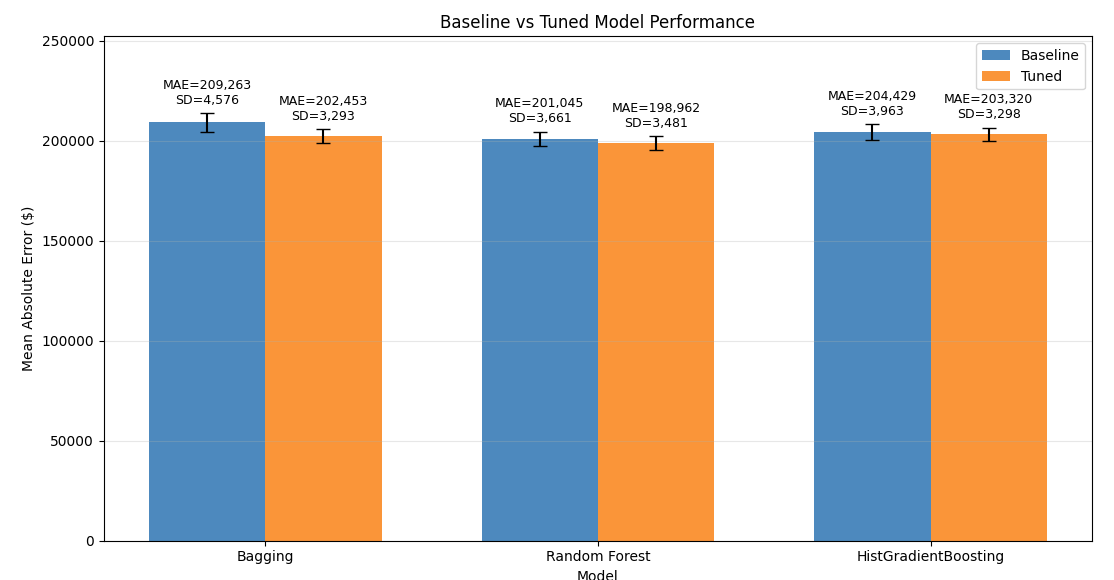

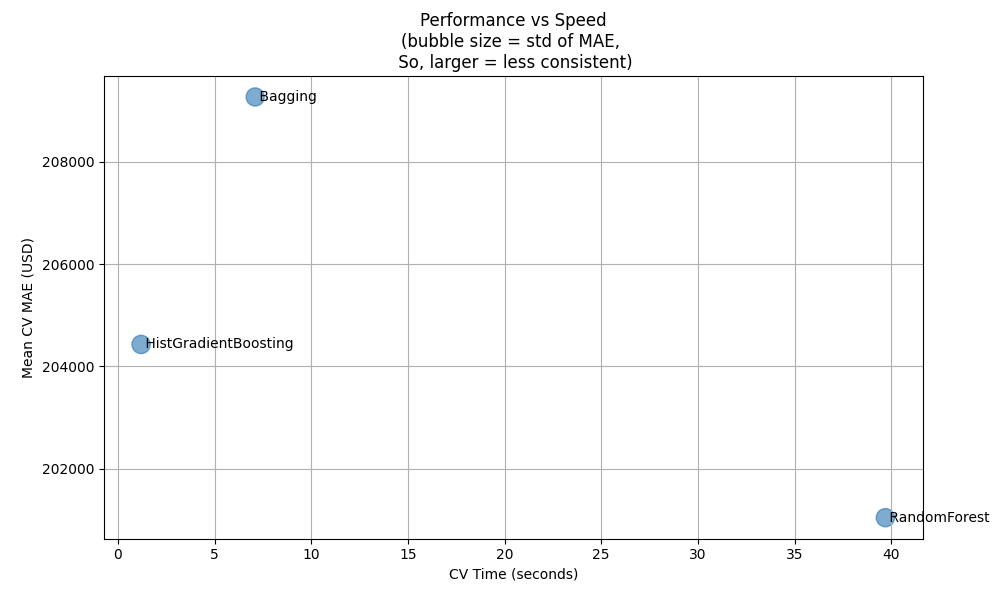

**Figure: Performance vs Speed**

- **Title**: Performance vs Speed (bubble size = std of MAE, so larger = less consistent)
- **X-axis**: CV Time (seconds)
- **Y-axis**: Mean CV MAE (USD)
- **Bubble size**: Standard deviation of MAE across validation folds

<br>

**Explanation of What the Plot Shows**

- This plot compares the models in terms of **accuracy**, **runtime**, and **consistency**. 
- **Random Forest** achieved the **lowest MAE** but required the **longest CV time**. 
- **HistGradientBoosting** was the **fastest model**, while **Bagging** was **intermediate** in speed but had the highest error. 
- Bubble size reflects **variability**, so larger bubbles indicate less consistent performance.

<br>

**Why This Visualization Matters**

- This visualization matters because it shows the <u>tradeoff between predictive performance and computational cost</u>. 
- It helps justify selecting Random Forest as the final model since it gave the best accuracy, while also showing that HistGradientBoosting may be preferable when speed is more important.

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving



**5.3 Answer:**  
<br>

**Patterns in Residuals or Prediction Errors**

- The error plots (*visualized in 5.2 Visualization Section*) show that prediction performance was **not uniform** across the housing market:
    - In the **residual plot**, most **lower-** and **mid-priced** homes were concentrated closer to the zero line, which indicates more **stable predictions** in those ranges. 
    - However, the residuals **spread out** noticeably as predicted price **increased**, creating a **wider** error band for higher-value homes. 
    - This means the model was more reliable for typical properties than for expensive ones.

<br>

**Overprediction or Underprediction**

- The clearest pattern was **underprediction** at the high end of the market:
    - In the **Actual vs Predicted plot** (*visualized in 5.2 Visualization Section*), several of the most expensive homes fell well below the 45-degree reference line, showing that the model predicted values <u>much lower than the actual sale prices</u>. 
    
- *Overprediction* was present in some cases, but it was less dominant than the underprediction pattern:
    - For example, the **Actual vs Predicted plot** includes a property with a predicted value near **$6 million** even though its **actual price was much lower**, placing it well above the 45-degree line. 
    - However, these cases were **less frequent** and less visually dominant than the underprediction pattern observed for very expensive homes.

- Overall, the model appears to shrink extreme prices toward the center. This means that unusually high or unusual house prices are often predicted closer to average market values. In Random Forest, this happens because the final prediction is an average across many trees, which improves stability but can smooth out rare extreme cases.

<br>

**Outliers or Unusual Observations**

- Both the **residual plot** and the **Actual vs Predicted plot** (*visualized in 5.2 Visualization Section*) showed a small number of observations with very large errors, especially large positive residuals, where actual prices were far above predicted values. 
- These points likely represent unusual or luxury properties whose value depends on factors not fully captured in the feature set, such as premium micro-location effects, special amenities, or rare property characteristics. 
- These outliers did not define the overall model behavior, but they reveal an important weakness in predicting extreme cases.

<br>

**Anything Surprising or Worth Improving**

- One important finding is that the model was **fairly stable** overall, but its largest **weaknesses** were concentrated in a relatively small number of **high-value** homes. 
- This suggests that the main issue was not general overfitting across the full dataset, but **limited ability** to model the upper tail of the price distribution. 
- A useful next step would be to <u>improve representation of luxury-market factors</u>, add richer location-based variables, or model the target on a log scale to reduce the influence of extreme prices. This could help reduce the strong underprediction pattern seen for very expensive homes.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
Replace this sentence with your answer.
